# Fine-Tuning D-DETR
[Deformable-DETR](https://github.com/fundamentalvision/Deformable-DETR)

This notebook takes inspiration from:
- [this](https://github.com/woctezuma/finetune-detr) notebook.
- [this]

**NOTE**: This notebook is intended to run on one of the UTM lab machines

## 0 Utility

In [1]:
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

torch.set_grad_enabled(True);

2.6.0+cu124 True


In [2]:
# GPU
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0)} bytes")
    print(f"Memory Cached: {torch.cuda.memory_reserved(0)} bytes")
    device = 'cuda'
else:
    print("No GPU found")
    device = 'cpu'
print(f"Current device: {device}")

GPU Name: NVIDIA GeForce RTX 4080
Memory Allocated: 0 bytes
Memory Cached: 0 bytes
Current device: cuda


In [3]:
import torchvision.transforms as T

# Standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

In [4]:
def filter_bboxes_from_outputs(outputs,
                               threshold=0.7):
  
  # keep only predictions with confidence above threshold
  probas = outputs['logits'].softmax(-1)[0, :, :-1]
  keep = probas.max(-1).values > threshold

  probas_to_keep = probas[keep]

  # convert boxes from [0; 1] to image scales
  bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], im.size)
  
  return probas_to_keep, bboxes_scaled

In [5]:
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

In [6]:
import matplotlib.pyplot as plt

def plot_results(pil_img, prob=None, boxes=None):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    if prob is not None and boxes is not None:
      for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
          ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                    fill=False, color=c, linewidth=3))
          cl = p.argmax()
          text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
          ax.text(xmin, ymin, text, fontsize=15,
                  bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

### 0-1 Load an image for a demo

In [7]:
from transformers import (DeformableDetrForObjectDetection, Trainer, TrainingArguments, default_data_collator)

model = DeformableDetrForObjectDetection.from_pretrained("SenseTime/deformable-detr")
model.eval()

2025-03-17 21:47:45.966400: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-17 21:47:45.977442: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742262465.990623 3153021 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742262465.994561 3153021 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-17 21:47:46.008371: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

DeformableDetrForObjectDetection(
  (model): DeformableDetrModel(
    (backbone): DeformableDetrConvModel(
      (conv_encoder): DeformableDetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DeformableDetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DeformableDetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DeformableDetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3):

In [8]:
from PIL import Image
import requests

url = 'https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftse4.mm.bing.net%2Fth%3Fid%3DOIP.eAqWL9pcyYZIiS2_8vDmLAHaEK%26pid%3DApi&f=1&ipt=0406327f984576a09a8168b38bb7eddee4fe0f4edac49ab45e76dcdd29f98754&ipo=images'
im = Image.open(requests.get(url, stream=True).raw)

In [9]:
img = transform(im).unsqueeze(0)

outputs = model(img)

In [10]:
print(outputs.keys())

odict_keys(['logits', 'pred_boxes', 'init_reference_points', 'last_hidden_state', 'intermediate_hidden_states', 'intermediate_reference_points', 'encoder_last_hidden_state'])


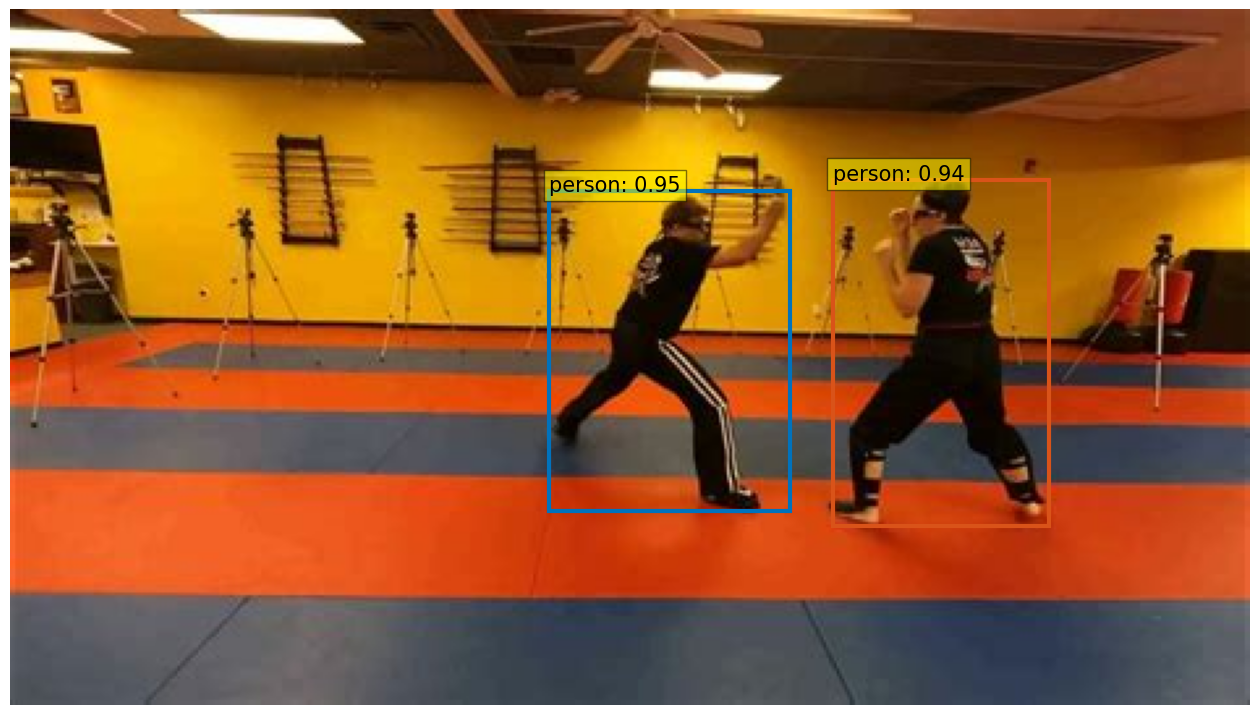

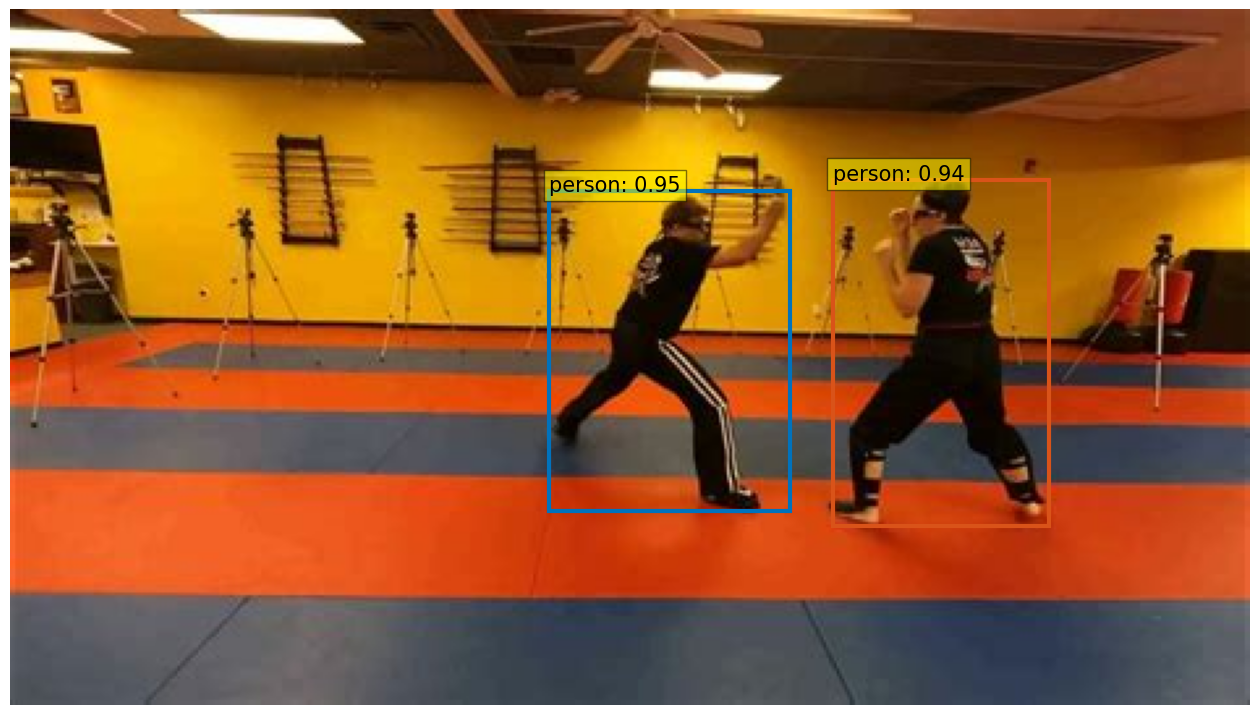

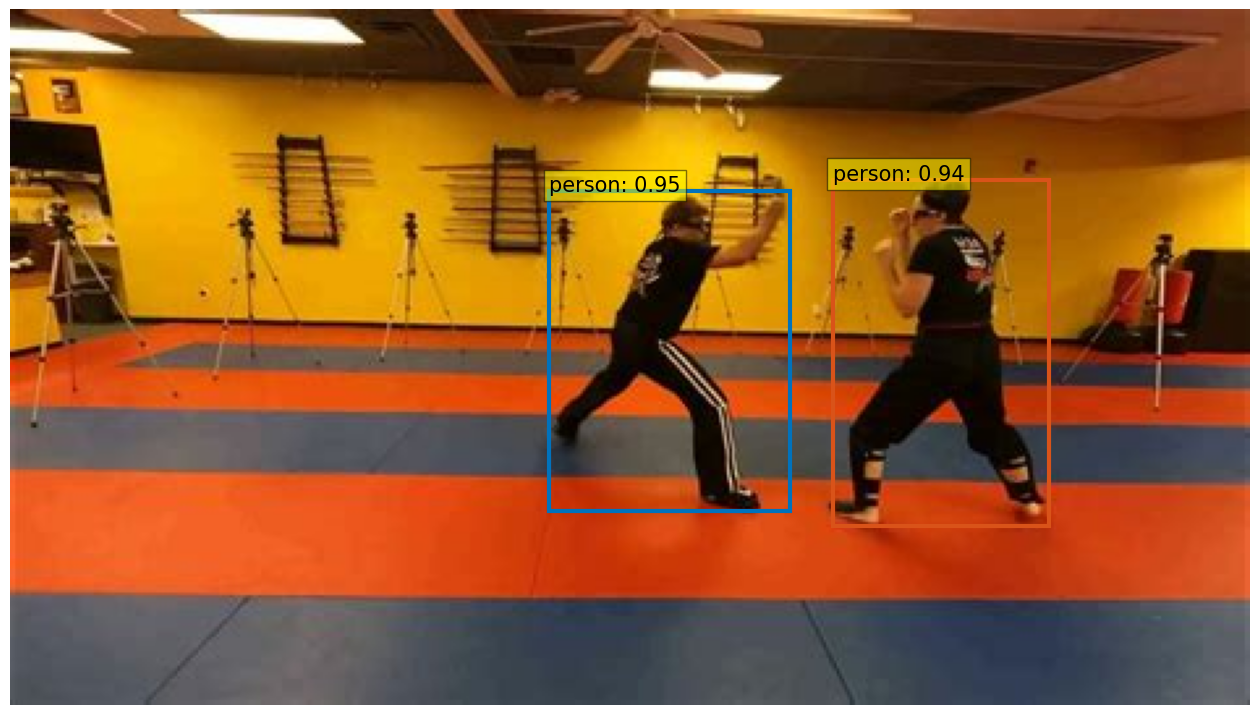

In [11]:

for threshold in [0.9, 0.7, 0.5]:
    probes_to_keep, bboxes_scaled = filter_bboxes_from_outputs(outputs, threshold=threshold)
    plot_results(im, probes_to_keep, bboxes_scaled)

## 1 Downloading the dataset (Harmony4D)

### 1-0 Directories and Environment

In [12]:
import os

USER = os.environ["USER"]
STORAGE_DIR = "/virtual/" + USER
DATASET_DIR = STORAGE_DIR + "/datasets"
ZIP_DIR = STORAGE_DIR + "/zips"

print(f"USER: {USER}\nSTORAGE_DIR: {STORAGE_DIR}\nDATASET_DIR: {DATASET_DIR}\nZIP_DIR: {ZIP_DIR}")

USER: poncema2
STORAGE_DIR: /virtual/poncema2
DATASET_DIR: /virtual/poncema2/datasets
ZIP_DIR: /virtual/poncema2/zips


### 1-1 Download the train and test datasets from HuggingFace Hub

In [13]:
from huggingface_hub import hf_hub_download

REPO_ID = "Jyun-Ting/Harmony4D"
TRAIN_FILENAME = "train/01_hugging.zip"
TEST_FILENAME = "test/01_hugging.zip"

print(f"Downloading from {REPO_ID}...")
train_path = hf_hub_download(repo_id=REPO_ID, filename=TRAIN_FILENAME, repo_type="dataset", local_dir=ZIP_DIR)
print(f"Dataset downloaded at: {train_path}")
test_path = hf_hub_download(repo_id=REPO_ID, filename=TEST_FILENAME, repo_type="dataset", local_dir=ZIP_DIR)
print(f"Dataset downloaded at: {test_path}")

Dataset downloaded at: /virtual/poncema2/zips/train/01_hugging.zip
Dataset downloaded at: /virtual/poncema2/zips/test/01_hugging.zip


In [14]:
import zipfile as zf
# Extract if necessary
# NOTE that for 01,02_hugging.zip, the extracted folders are
# 01_hugging.zip -> 001_hugging
# 02_hugging.zip -> 002_hugging

if not os.path.exists(os.path.join(DATASET_DIR, "01_hugging")):
    print(f"Extracting datasets...")
    with zf.ZipFile(train_path, "r") as zip_ref:
        zip_ref.extractall(DATASET_DIR)

    with zf.ZipFile(test_path, "r") as zip_ref:
        zip_ref.extractall(DATASET_DIR)
else:
    print(f"Datasets already extracted at {DATASET_DIR}")

Datasets already extracted at /virtual/poncema2/datasets


In [15]:
# Visualize some random samples to confirm we've read correctly


### 1-2 Convert into Datasets Object

In [16]:
import glob
# Load the paths of the images and bounding boxes
def load_dataset_paths_from_directory(data_dir, split="train"):
    image_dir = os.path.join(data_dir, "exo")
    bbox_dir = os.path.join(data_dir, "processed_data", "bbox")

    image_paths = []
    bbox_paths = []
    
    print(f"Loading {split} dataset paths... from {image_dir} and {bbox_dir}")
    for cam_folder in sorted(os.listdir(image_dir)):
        cam_image_dir = os.path.join(image_dir, cam_folder, "images")
        cam_bbox_dir = os.path.join(bbox_dir, cam_folder)

        # List all image files in the cam folder
        image_files = sorted(glob.glob(os.path.join(cam_image_dir, "*.jpg")))
        bbox_files = sorted(glob.glob(os.path.join(cam_bbox_dir, "*.npy")))

        # Ensure the number of images and bounding boxes match
        assert len(image_files) == len(bbox_files)

        # Add image and bbox paths to the lists
        for img_path, bbox_path in zip(image_files, bbox_files):
            image_paths.append(img_path)
            bbox_paths.append(bbox_path)

    print(f"Loaded {len(image_paths)} image and {len(bbox_paths)} bounding box paths")

    return image_paths, bbox_paths

In [23]:
from datasets import IterableDataset
import numpy as np

def generator(path=DATASET_DIR, split="train"):
    image_paths, bbox_paths = load_dataset_paths_from_directory(path, split)
    for img_id, (img_path, bbox_path) in enumerate(zip(image_paths, bbox_paths)):
        img = Image.open(img_path).convert("RGB")
        img = transform(img)
        bbox_data = np.load(bbox_path, allow_pickle=True).item()
        # The bboxes are stored like {"aria01" : [x1, y1, x2, y2], "aria02": [x1, y1, x2, y2], ...}
        # but are type numpy.ndarray
        # The model expects a tensor
        annotations = []
        for obj_id, bbox in bbox_data.items():
            x_min, y_min, x_max, y_max = bbox
            width = x_max - x_min
            height = y_max - y_min

            area = width * height

            annotations.append({
                "bbox": torch.tensor([x_min, y_min, width, height], dtype=torch.float32),
                "area": area,
                "category_id": 1,
                "iscrowd": 1
            })
        
        yield {
            "image": img,
            "annotations": {
                "image_id": img_id,
                "annotations": annotations
            }
        }

In [24]:
# Create datasets

train_path = os.path.join(DATASET_DIR, "01_hugging", "001_hugging")
test_path = os.path.join(DATASET_DIR, "01_hugging", "002_hugging")


train_dataset = IterableDataset.from_generator(generator, gen_kwargs={"path": train_path, "split": "train"})
test_dataset = IterableDataset.from_generator(generator, gen_kwargs={"path": test_path, "split": "test"})

In [25]:
# Processing with DeformableDetrImageProcessor
from transformers import AutoImageProcessor

# processor = DeformableDetrImageProcessor.from_pretrained("SenseTime/deformable-detr")
processor = AutoImageProcessor.from_pretrained("SenseTime/deformable-detr", use_fast=True)

In [28]:
# PyTorch DataLoader
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=1, collate_fn=lambda x: x)
test_dataloader = DataLoader(test_dataset, batch_size=1, collate_fn=lambda x: x)

## 2 Train

In [ ]:
from tqdm import tqdm
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Training loop:
print(f"Beginning training...\nDevice: {device}")

model.gradient_checkpointing_enable()

model.to(device)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    
    # Initialize tracking variables
    running_loss = 0.0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", dynamic_ncols=True)
    
    for batch_idx, batch in enumerate(progress_bar):    
        images = [item['image'] for item in batch]
        annotations = [item['annotations'] for item in batch]
        

        # prepare targets        
        targets = []
        for annotation in annotations:
            labels = []
            boxes = []
            image_id = annotation['image_id']
            _annotations = annotation['annotations'] # list of dictionaries
            for ann in _annotations:
                boxes.append(ann['bbox'])
                labels.append(ann['category_id'])
            
            # convert boxes into the right format
            boxes = torch.stack([torch.tensor(box) for box in boxes], dim=0)

            # create the target dict for each image
            targets.append({
                'image_id': image_id,
                'class_labels': torch.tensor(labels).to(device),
                'boxes': boxes.to(device)
            })

        # prepare inputs
        inputs = processor(images=images, return_tensors="pt")
        inputs = {key: value.to(device) for key, value in inputs.items()}
        
        # Forward pass: Get predictions
        outputs = model(**inputs, labels=targets)
        
        # Calculate loss (DeformableDETR automatically handles this internally)
        loss = outputs.loss
        running_loss += loss.item()

        # Backward pass and optimization
        optimizer.zero_grad()  # Reset gradients
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update model parameters
        
        # Update learning rate scheduler
        lr_scheduler.step()
        
        # Update the progress bar
        avg_loss = running_loss / (batch_idx + 1)
        progress_bar.set_postfix(loss=avg_loss)
    
    # End of epoch
    avg_epoch_loss = running_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs} finished. Loss: {avg_epoch_loss:.4f}")
    
    # Save model checkpoint
    model.save_pretrained(f"checkpoint_epoch_{epoch+1}")
    processor.save_pretrained(f"checkpoint_epoch_{epoch+1}")


Beginning training...
Device: cuda


Epoch 1/10: 0it [00:00, ?it/s]

Loading train dataset paths... from /virtual/poncema2/datasets/01_hugging/001_hugging/exo and /virtual/poncema2/datasets/01_hugging/001_hugging/processed_data/bbox
Loaded 6622 image and 6622 bounding box paths


/tmp/ipykernel_3153021/3807310825.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  boxes = torch.stack([torch.tensor(box) for box in boxes], dim=0)
Epoch 1/10: 291it [02:11,  2.34it/s, loss=2.11e+4]